In [1]:
print("Welcome to Ecommerce Purchase Intent Prediction!")

Welcome to Ecommerce Purchase Intent Prediction!


In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("All libraries imported successfully!")


All libraries imported successfully!


In [9]:
import pandas as pd

df = pd.read_csv("data/raw/ecommerce_purchase_intent.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Converted
0,1,14.6517,0,0.0000,19,283.8812,0.008014,0.042106,68.579222,0.0,June,1,2,1,1,Returning_Visitor,False,1
1,1,18.9189,2,54.9802,15,1241.7638,0.032395,0.058101,0.000000,0.0,May,2,1,8,12,Returning_Visitor,False,0
2,1,30.0198,0,0.0000,23,365.3384,0.006802,0.029451,0.000000,0.0,Mar,1,2,1,3,New_Visitor,True,0
3,1,6.5566,0,0.0000,6,687.4788,0.039577,0.104395,0.000000,0.6,Dec,1,1,1,2,Returning_Visitor,True,0
4,1,112.5842,1,36.3523,19,656.4535,0.004594,0.038321,0.000000,0.0,Mar,2,1,2,5,Returning_Visitor,False,0


In [10]:
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Converted
0,1,14.6517,0,0.0000,19,283.8812,0.008014,0.042106,68.579222,0.0,June,1,2,1,1,Returning_Visitor,False,1
1,1,18.9189,2,54.9802,15,1241.7638,0.032395,0.058101,0.000000,0.0,May,2,1,8,12,Returning_Visitor,False,0
2,1,30.0198,0,0.0000,23,365.3384,0.006802,0.029451,0.000000,0.0,Mar,1,2,1,3,New_Visitor,True,0
3,1,6.5566,0,0.0000,6,687.4788,0.039577,0.104395,0.000000,0.6,Dec,1,1,1,2,Returning_Visitor,True,0
4,1,112.5842,1,36.3523,19,656.4535,0.004594,0.038321,0.000000,0.0,Mar,2,1,2,5,Returning_Visitor,False,0
5,1,43.0100,1,13.0757,13,105.5040,0.025687,0.064924,0.000000,0.0,May,3,2,1,15,New_Visitor,False,0
6,1,7.2378,1,57.0617,27,1250.6608,0.023220,0.048820,29.298696,0.0,May,1,1,1,13,Returning_Visitor,True,1
7,1,9.6154,0,0.0000,7,134.0504,0.034407,0.113875,0.000000,0.0,Nov,2,1,1,6,Returning_Visitor,False,0
8,4,74.7781,1,10.5020,35,3417.7199,0.013878,0.004163,0.000000,0.0,Nov,1,1,2,19,Returning_Visitor,False,0
9,0,0.0000,1,20.1697,7,297.5419,0.037608,0.082953,6.617230,0.0,May,1,1,7,20,Returning_Visitor,False,0


In [11]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 12000
Columns: 18


In [12]:
df.columns.tolist()

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend',
 'Converted']

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12000 non-null  int64  
 1   Administrative_Duration  12000 non-null  float64
 2   Informational            12000 non-null  int64  
 3   Informational_Duration   12000 non-null  float64
 4   ProductRelated           12000 non-null  int64  
 5   ProductRelated_Duration  12000 non-null  float64
 6   BounceRates              12000 non-null  float64
 7   ExitRates                12000 non-null  float64
 8   PageValues               12000 non-null  float64
 9   SpecialDay               12000 non-null  float64
 10  Month                    12000 non-null  object 
 11  OperatingSystems         12000 non-null  int64  
 12  Browser                  12000 non-null  int64  
 13  Region                   12000 non-null  int64  
 14  TrafficType           

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12000.0,1.888667,1.465361,0.0,1.000000,2.000000,3.000000,11.000000
Administrative_Duration,12000.0,42.311715,49.031915,0.0,11.768900,28.511250,56.383875,659.468000
Informational,12000.0,0.545667,0.754848,0.0,0.000000,0.000000,1.000000,6.000000
Informational_Duration,12000.0,13.548495,25.073544,0.0,0.000000,0.000000,19.933500,397.166500
ProductRelated,12000.0,19.832083,13.170700,0.0,11.000000,17.000000,25.000000,156.000000
ProductRelated_Duration,12000.0,723.097053,763.561517,0.0,268.158750,499.425850,902.039425,10154.158900
BounceRates,12000.0,0.021219,0.015549,0.0,0.008306,0.020064,0.031951,0.088727
ExitRates,12000.0,0.054104,0.026335,0.0,0.035625,0.053757,0.071956,0.158354
PageValues,12000.0,12.229337,25.858819,0.0,0.000000,0.000000,12.913332,418.113564
SpecialDay,12000.0,0.061117,0.204577,0.0,0.000000,0.000000,0.000000,1.000000


In [15]:
df.isnull().sum()


Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Converted                  0
dtype: int64

In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [17]:
df["Converted"].value_counts()


Converted
0    10114
1     1886
Name: count, dtype: int64

In [18]:
(df["Converted"].value_counts(normalize=True) * 100).round(2)

Converted
0    84.28
1    15.72
Name: proportion, dtype: float64

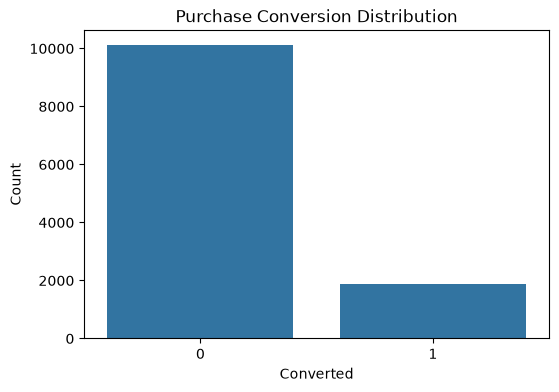

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Converted")

plt.title("Purchase Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Count")

plt.show()

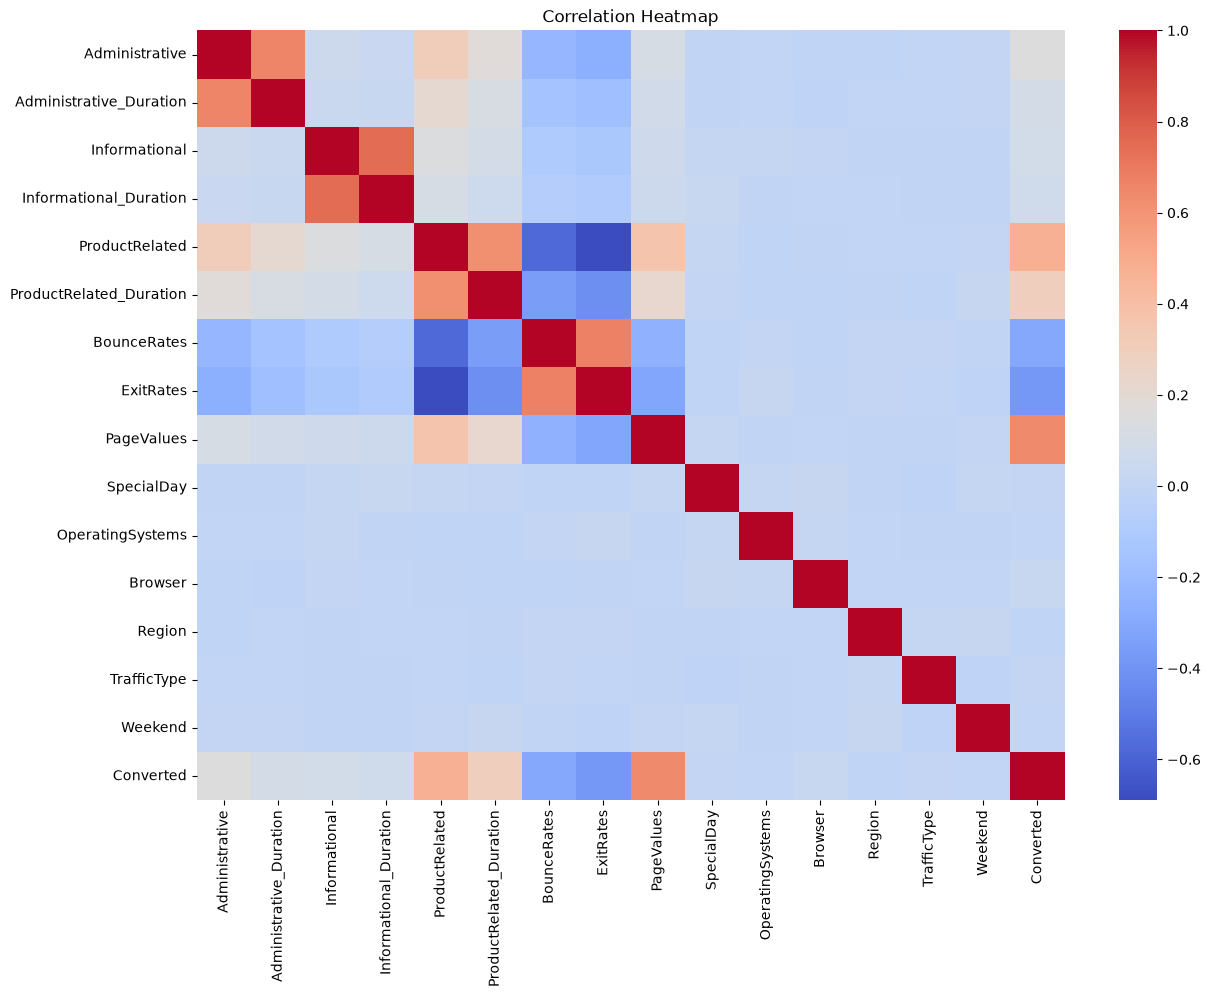

In [20]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

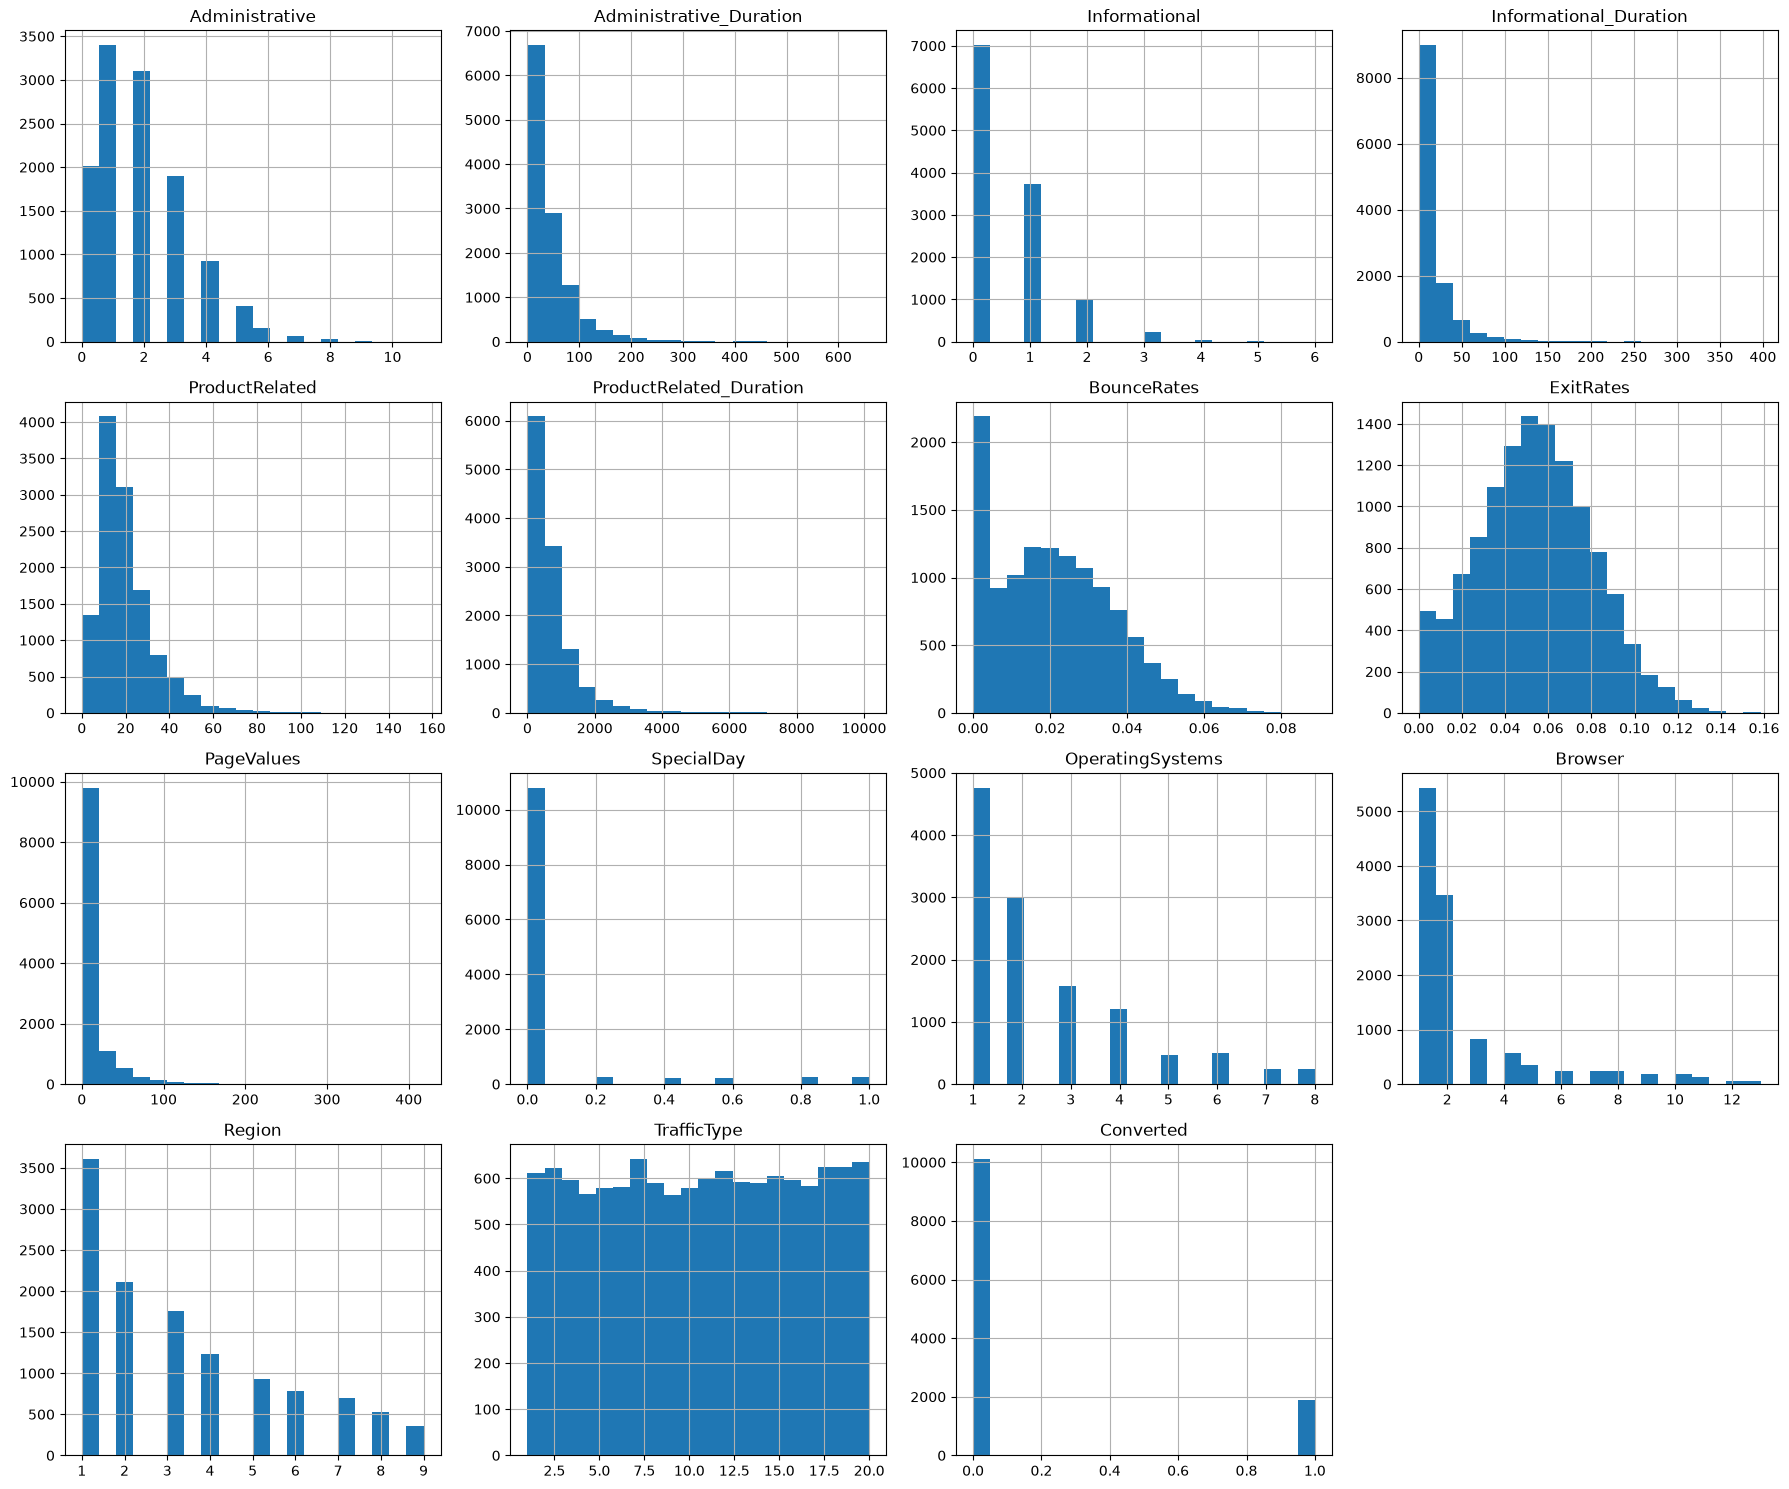

In [21]:
df.hist(figsize=(18,15), bins=20)

plt.tight_layout()
plt.show()